<a href="https://colab.research.google.com/github/NadeenAlaqeel625/AI-Models/blob/main/speech_to_text_whisper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

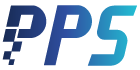

<div dir="rtl" align="right">

# نظام معالجة وتحويل الصوت إلى نص

أداة داخلية مقدّمة من **Pixel Professional Solutions** لمعالجة الملفات الصوتية وتحويل محتواها إلى نص باستخدام تقنيات الذكاء الاصطناعي ونموذج **Whisper**.

### خطوات الاستخدام

**1. تشغيل النظام**  
قم بتشغيل خلية التثبيت الأولى لتحضير بيئة العمل وتثبيت المكتبات المطلوبة.

**2. رفع الملف الصوتي**  
قم برفع الملف الصوتي المراد معالجته.

**3. اختيار نموذج المعالجة**  
اختر حجم نموذج Whisper المناسب بناءً على السرعة والدقة المطلوبة.

**4. بدء معالجة الصوت**  
قم بتشغيل خلية **Transcription** لبدء تحليل الملف وتحويل الكلام إلى نص.

**5. مراجعة النص الناتج**  
بعد انتهاء المعالجة، سيظهر النص المستخرج من التسجيل.

**6. تصدير النص**  
يمكن حفظ النص الناتج وتنزيله لاستخدامه في التقارير والتوثيق وتحليل الاجتماعات.

### ملاحظات مهمة

- يدعم النظام **اللغة العربية والإنجليزية**.
- يمكن اختيار نموذج أكبر للحصول على دقة أعلى.
- يُنصح بتفعيل **GPU T4** لتسريع المعالجة.

</div>

## 1. تثبيت المكتبات المطلوبة

>



In [1]:
!pip install -q faster-whisper

import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 43.8 MB/s eta 0:00:00
GPU available: False


## 2. رفع ملف الصوت



In [10]:
# الطريقة 1: رفع مباشر من جهازك
from google.colab import files

uploaded = files.upload()
audio_path = list(uploaded.keys())[0]
print("تم رفع الملف:", audio_path)

Saving WhatsApp Ptt 2026-09-07 at 07.50.16.ogg to WhatsApp Ptt 2026-09-07 at 07.50.16.ogg
تم رفع الملف: WhatsApp Ptt 2026-09-07 at 07.50.16.ogg


## 3. تحميل الموديل

اختر الحجم حسب حاجتك:

| الموديل | السرعة | الدقة | يدعم عربي؟ |
|---|---|---|---|
| `base` | سريع جداً | متوسطة | نعم |
| `small` | سريع | جيدة | نعم |
| `medium` | متوسط | جيدة جداً | نعم (موصى به) |
| `large-v3` | أبطأ | الأفضل | نعم (الأدق للعربي) |

In [11]:
from faster_whisper import WhisperModel

MODEL_SIZE = "medium"  # غيّرها لـ "large-v3" لو بدك أعلى دقة، أو "small" لو بدك أسرع

device = "cuda" if torch.cuda.is_available() else "cpu"
compute_type = "float16" if device == "cuda" else "int8"

print(f"Loading model '{MODEL_SIZE}' on {device} ({compute_type})...")
model = WhisperModel(MODEL_SIZE, device=device, compute_type=compute_type)
print("تم تحميل الموديل بنجاح.")

Loading model 'medium' on cpu (int8)...
تم تحميل الموديل بنجاح.


## 4. تشغيل التفريغ الصوتي (Transcription)

اترك `language=None` ليكتشف اللغة تلقائياً، أو حدد `"ar"` للعربي أو `"en"` للإنجليزي لتسريع المعالجة.

In [12]:
LANGUAGE = None  # أو "ar" أو "en"

segments, info = model.transcribe(
    audio_path,
    beam_size=5,
    language=LANGUAGE,
    vad_filter=True,  # يتخطى فترات الصمت لتسريع المعالجة
)

print(f"اللغة المكتشفة: {info.language} (احتمالية: {info.language_probability:.2f})\n")

full_text = []
for segment in segments:
    line = f"[{segment.start:.2f}s -> {segment.end:.2f}s] {segment.text}"
    print(line)
    full_text.append(segment.text.strip())

full_text = " ".join(full_text)

اللغة المكتشفة: ar (احتمالية: 0.97)

[0.14s -> 2.14s]  صباح الخير بها كيف حالك؟
[3.14s -> 5.14s]  بها أنا اليوم برضه ما رح أقدر أجي معكم تمام
[6.14s -> 9.14s]  بس أعذرني أنا كنت مكن ما بعرف اللي أخبرتك لنا ولا لا
[10.14s -> 12.14s]  بس كنت برا عمان
[13.14s -> 15.14s]  وليك شو هاي الفترة معجوقه الصباح
[15.14s -> 17.14s]  فعم بصحة متأخر
[17.14s -> 19.14s]  وعم بصحة متأخر لبس أهند الأموري


## 5. عرض النص الكامل وحفظه

In [5]:
print("النص الكامل:\n")
print(full_text)

output_filename = "transcript.txt"
with open(output_filename, "w", encoding="utf-8") as f:
    f.write(full_text)

print(f"\nتم حفظ النص في: {output_filename}")

النص الكامل:

اسمعي كيفك؟ أريد أن أسألك هل لو بدنا نعمل احنا موديل على كولاب كيف يكون الوضع وبس والله وردي لي خبر يعني بأقرب وقت

تم حفظ النص في: transcript.txt


In [6]:
# تنزيل ملف النص إلى جهازك
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>